In [1]:
using SpecialFunctions
# using StatsPlots
using CairoMakie
using FileIO
using DataFrames
using DataFramesMeta
using EM
filepath = ".."
include("$(filepath)/code/hmm.jl")
include("$(filepath)/code/hmm_independentsamedist.jl")
include("$(filepath)/code/qlearner.jl")
include("$(filepath)/code/util.jl")
include("$(filepath)/code/em_scripts.jl");

In [2]:
data = Dict()
for animal in animals
    data[animal] = load_animal(animal, "..")
end

In [3]:
# Correspondence of sessions and days
animal_session_info = Dict()
for animal in animals
    firstrows = combine(first, groupby(load_animal(animal, ".."), :daysessionnum))[:, [:date, :daysessionnum, :daynum, :session]]
    nrows = combine(nrow, groupby(load_animal(animal, ".."), :daysessionnum))
    animal_session_info[animal] = innerjoin(firstrows, nrows, on=:daysessionnum)
end

In [4]:
# Correspondence of sessions and days
animal_day_info = Dict()
for animal in animals
    firstrows = combine(first, groupby(load_animal(animal, ".."), :daynum))[:, [:date, :daynum, :session]]
    nrows = combine(nrow, groupby(load_animal(animal, ".."), :daynum))
    animal_day_info[animal] = innerjoin(firstrows, nrows, on=:daynum)
end

# Model Comparison

First, we have an "old" model comparison where the value of the current stem is solely determined by the upcoming leaf, rather than a weighted sum of the two of them.

We see a massive hit to model fits (the negative values compared to the full value) of either of two models:
1. Independent HMM, where each leaf is its own HMM
2. Local-stem-only HMM, which only determines stay/go as a function of the current stem versus stay bias

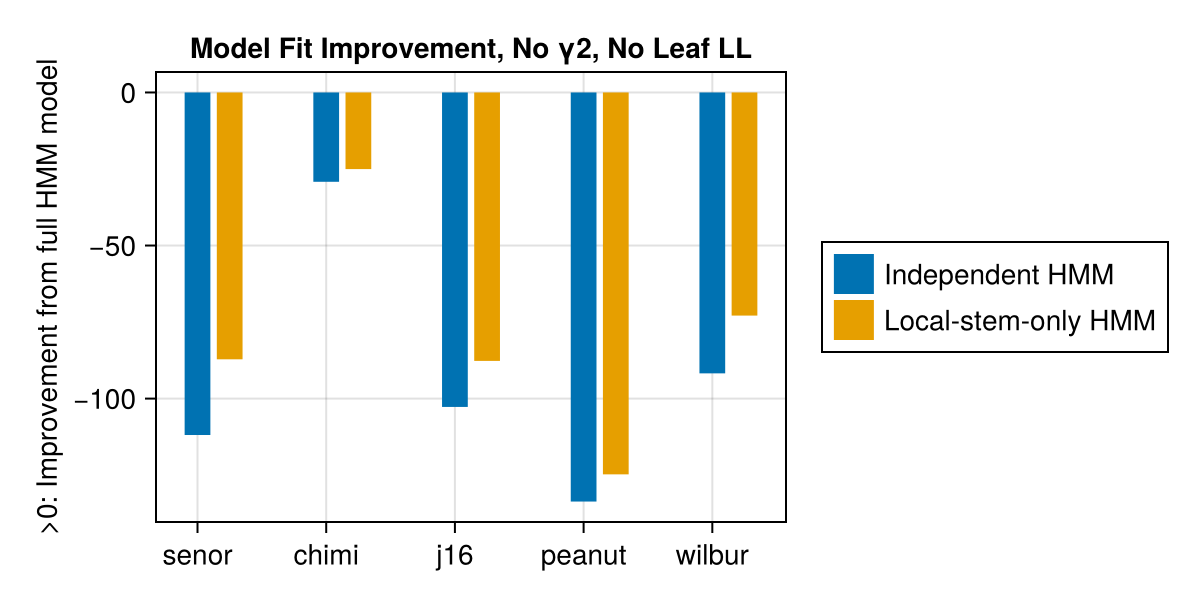

In [26]:
f = Figure(size=(600,300))
colors = Makie.wong_colors()

ax = Axis(f[1,1], ylabel=">0: Improvement from full HMM model", xticks=((1:5)*4, animals), title="Model Fit Improvement, No γ2, No Leaf LL")
for (i, animal) in enumerate(animals)
    x1 = load("$(filepath)/results/hmm_biases/hmm_stay_turn_$(animal).jld2", "results")
    x2 = load("$(filepath)/results/hmm_independentsamedist_biases/hmm_independentsamedist_stay_turn_$(animal).jld2", "results")
    x3 = load("$(filepath)/results/hmm_nononlocal_biases/hmm_stay_turn_$(animal).jld2", "results")
    # x4 = load("$(filepath)/results/q_biases/q_initialQ_stay_turn_γ2_decay_$(animal).jld2", "results")
    if (i == 1)
        barplot!(i*4, iaic(x1) - iaic(x2), color=colors[1], label="Independent HMM")
        barplot!(i*4+1, iaic(x1) - iaic(x3), color=colors[2], label="Local-stem-only HMM")
        # barplot!(i*4+2, iaic(x1) - iaic(x4), color=colors[3], label="Independent, V=Both Leaves")
    else
        barplot!(i*4, iaic(x1) - iaic(x2), color=colors[1])
        barplot!(i*4+1, iaic(x1) - iaic(x3), color=colors[2])
        # barplot!(i*4+2, iaic(x1) - iaic(x4), color=colors[3])
    end
end
Legend(f[1,2], ax)
f

Next, we include γ2 - so value of the current stem is (1-γ2) * upcoming leaf + γ2 * previous leaf

Comparisons are
1. Independent HMM, where each leaf is its own HMM
2. Local-stem-only HMM, which only determines stay/go as a function of the current stem versus stay bias
3. Also now including old leaf weighting full HMM

Here, we still see the full model provides a better fit to behavior, but to a much smaller degree (and for unclear reasons, chimi with his different behavioral setup looks like a tossup)

The full model with the new leaf weighting also shows a significant improvement over the old one (green bar)

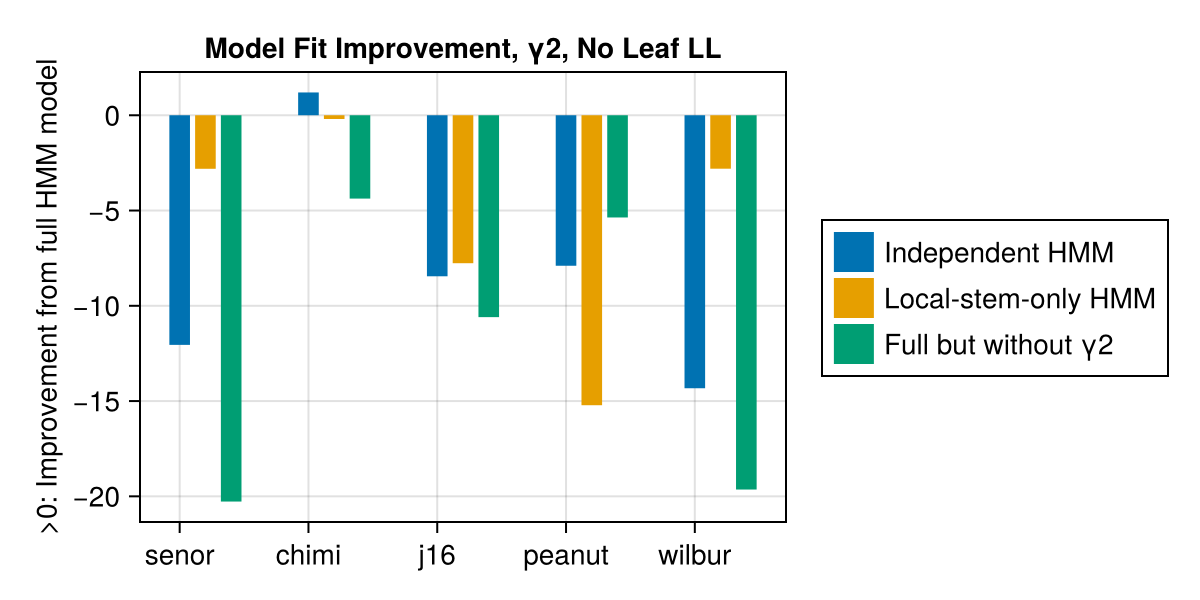

In [29]:
f = Figure(size=(600,300))
colors = Makie.wong_colors()

ax = Axis(f[1,1], ylabel=">0: Improvement from full HMM model", xticks=((1:5)*5, animals), title="Model Fit Improvement, γ2, No Leaf LL")
for (i, animal) in enumerate(animals)
    x1 = load("$(filepath)/results/hmm_biases/hmm_stay_turn_γ2_$(animal).jld2", "results")
    x2 = load("$(filepath)/results/hmm_independentsamedist_biases/hmm_independentsamedist_stay_turn_γ2_$(animal).jld2", "results")
    x3 = load("$(filepath)/results/hmm_nononlocal_biases/hmm_stay_turn_γ2_$(animal).jld2", "results")
    x4 = load("$(filepath)/results/hmm_biases/hmm_stay_turn_$(animal).jld2", "results")
    # x4 = load("$(filepath)/results/q_biases/q_initialQ_stay_turn_γ2_decay_$(animal).jld2", "results")
    if (i == 1)
        barplot!(i*5, iaic(x1) - iaic(x2), color=colors[1], label="Independent HMM")
        barplot!(i*5+1, iaic(x1) - iaic(x3), color=colors[2], label="Local-stem-only HMM")
        barplot!(i*5+2, iaic(x1) - iaic(x4), color=colors[3], label="Full but without γ2")
    else
        barplot!(i*5, iaic(x1) - iaic(x2), color=colors[1])
        barplot!(i*5+1, iaic(x1) - iaic(x3), color=colors[2])
        barplot!(i*5+2, iaic(x1) - iaic(x4), color=colors[3])
    end
end
Legend(f[1,2], ax)
f

Finally, some comparisons with the Q-learning model

Again, like before, starting with the old way of determining stem value (only the upcoming leaf), Q-learning shows generally (and again chimi is an exception for some reason) worse performance, even with models incorporating most HMM-like ideas.

Initial starting value means we fit what naive Q-values start as, decay means on each timestep they decay back to that initial value.

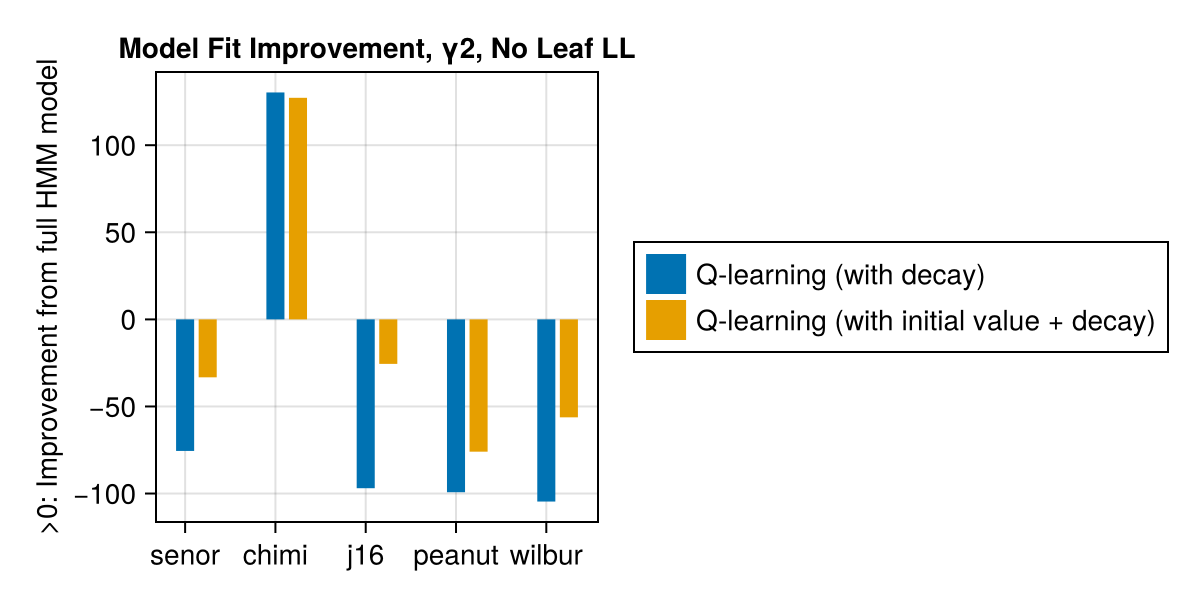

In [27]:
f = Figure(size=(600,300))
colors = Makie.wong_colors()

ax = Axis(f[1,1], ylabel=">0: Improvement from full HMM model", xticks=((1:5)*4, animals), title="Model Fit Improvement, no γ2, No Leaf LL")
for (i, animal) in enumerate(animals)
    x1 = load("$(filepath)/results/hmm_biases/hmm_stay_turn_$(animal).jld2", "results")
    x2 = load("$(filepath)/results/q_biases/q_stay_turn_decay_$(animal).jld2", "results")
    x3 = load("$(filepath)/results/q_biases/q_initialQ_stay_turn_decay_$(animal).jld2", "results")
    if (i == 1)
        barplot!(i*4, iaic(x1) - iaic(x2), color=colors[1], label="Q-learning (with decay)")
        barplot!(i*4+1, iaic(x1) - iaic(x3), color=colors[2], label="Q-learning (with initial value + decay)")
    else
        barplot!(i*4, iaic(x1) - iaic(x2), color=colors[1])
        barplot!(i*4+1, iaic(x1) - iaic(x3), color=colors[2])
    end
end
Legend(f[1,2], ax)
f

Here below, we add in γ2 - and now we see that the Q-learning model can be quite competitive with the HMM - seems like quite a bit comes down to this leaf weighting question

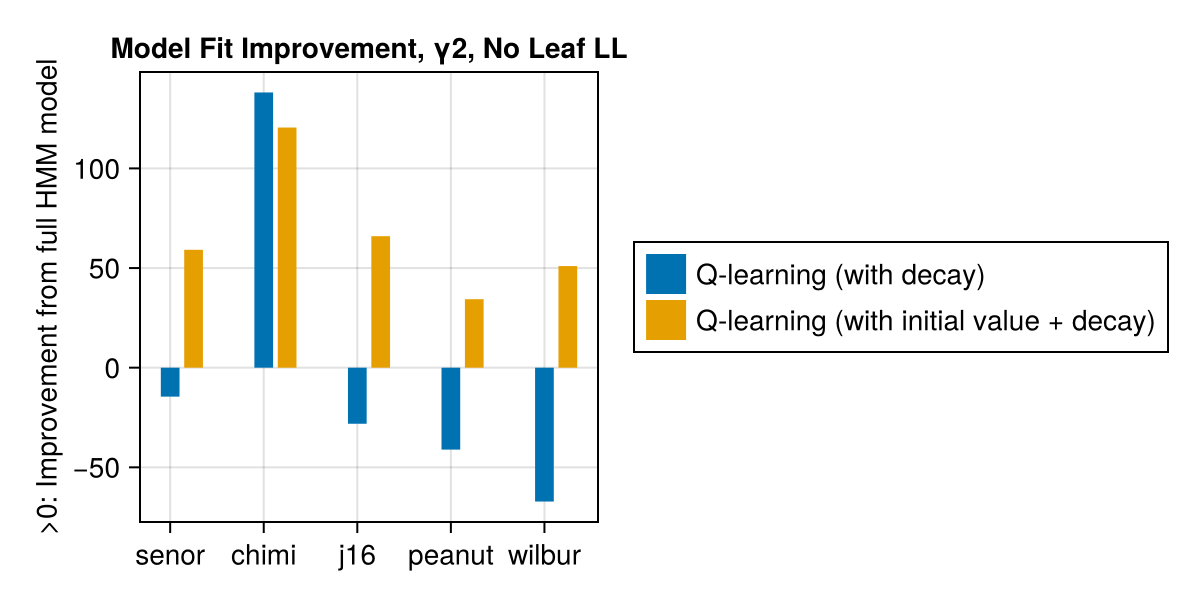

In [24]:
f = Figure(size=(600,300))
colors = Makie.wong_colors()

ax = Axis(f[1,1], ylabel=">0: Improvement from full HMM model", xticks=((1:5)*4, animals), title="Model Fit Improvement, γ2, No Leaf LL")
for (i, animal) in enumerate(animals)
    x1 = load("$(filepath)/results/hmm_biases/hmm_stay_turn_γ2_$(animal).jld2", "results")
    x2 = load("$(filepath)/results/q_biases/q_stay_turn_γ2_decay_$(animal).jld2", "results")
    x3 = load("$(filepath)/results/q_biases/q_initialQ_stay_turn_γ2_decay_$(animal).jld2", "results")
    if (i == 1)
        barplot!(i*4, iaic(x1) - iaic(x2), color=colors[1], label="Q-learning (with decay)")
        barplot!(i*4+1, iaic(x1) - iaic(x3), color=colors[2], label="Q-learning (with initial value + decay)")
    else
        barplot!(i*4, iaic(x1) - iaic(x2), color=colors[1])
        barplot!(i*4+1, iaic(x1) - iaic(x3), color=colors[2])
    end
end
Legend(f[1,2], ax)
f

# Figure 1F

Stay value vs. switch value

## With Leaf

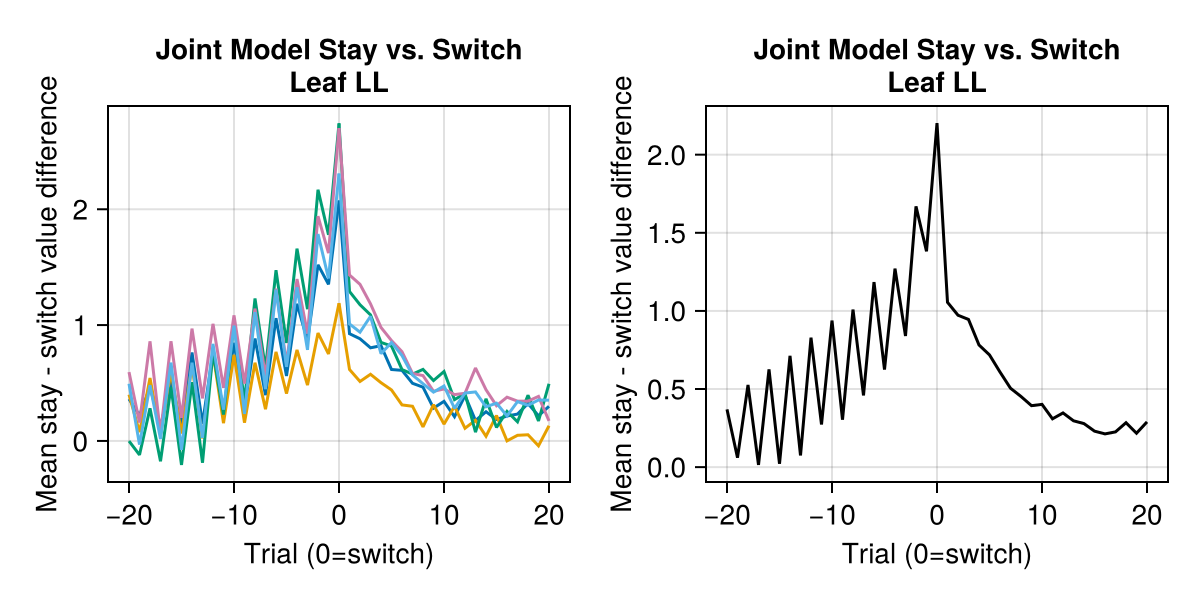

In [ ]:
f = Figure(size=(600,300))
colors = Makie.wong_colors()

nobias_dict = Dict(
    :stay_bias=>0.0,
    :turn_bias=>0.0,
    :spatial_bias=>[0.0, 0.0, 0.0],
)
rewscaled = false
rewscaled_file = rewscaled ? "_rewscaled" : ""
rewscaled_title = rewscaled ? "Rewscaled, " : ""
add_leaf = true
add_leaf_file = add_leaf ? "_leaf" : ""
add_leaf_title = add_leaf ? "" : "No "
add_γ2 = false
add_γ2_file = add_γ2 ? "_γ2" : ""
add_γ2_title = add_γ2 ? "γ2, " : ""

ax1 = Axis(f[1,1], ylabel="Mean stay - switch value difference", xlabel="Trial (0=switch)", title="Joint Model Stay vs. Switch\n$(rewscaled_title)$(add_γ2_title)$(add_leaf_title)Leaf LL")
for (i, animal) in enumerate(animals)
    x1 = load("$(filepath)/results/hmm_biases/hmm$(add_leaf_file)_stay_turn_leafspatial$(add_γ2_file)$(rewscaled_file)_$(animal).jld2", "results")
    q1 = find_Q_vals_hmm(data[animal], x1; add_leaf, rewscaled, delay_turn_bias=false, params=nobias_dict)
    q1[:, :choice_diff] .= log.(1 ./ q1.stem_stay_p .- 1)
    
    choice_diff_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 21) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :choice_diff => mean => :choice_diff)
    choice_diff_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 21) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :choice_diff => mean => :choice_diff)

    lines!(-choice_diff_by_day_q1_pre.n_pre_switch, choice_diff_by_day_q1_pre.choice_diff, color=colors[i], label=animal)
    lines!(choice_diff_by_day_q1_post.n_post_switch, choice_diff_by_day_q1_post.choice_diff, color=colors[i])
end

ax2 = Axis(f[1,2], ylabel="Mean stay - switch value difference", xlabel="Trial (0=switch)", title="Joint Model Stay vs. Switch\n$(rewscaled_title)$(add_γ2_title)$(add_leaf_title)Leaf LL")
choice_diffs = zeros(41)

for (i, animal) in enumerate(animals)
    x1 = load("$(filepath)/results/hmm_biases/hmm$(add_leaf_file)_stay_turn_leafspatial$(add_γ2_file)$(rewscaled_file)_$(animal).jld2", "results")
    q1 = find_Q_vals_hmm(data[animal], x1; add_leaf, rewscaled, delay_turn_bias=false, params=nobias_dict)
    q1[:, :choice_diff] .= log.(1 ./ q1.stem_stay_p .- 1)
    
    choice_diff_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 21) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :choice_diff => mean => :choice_diff)
    choice_diff_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 21) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :choice_diff => mean => :choice_diff)

    choice_diffs[21:-1:1] .+= choice_diff_by_day_q1_pre.choice_diff
    choice_diffs[22:41] .+= choice_diff_by_day_q1_post.choice_diff[2:end]
end
lines!(-20:20, choice_diffs ./ length(animals), color="black")

f

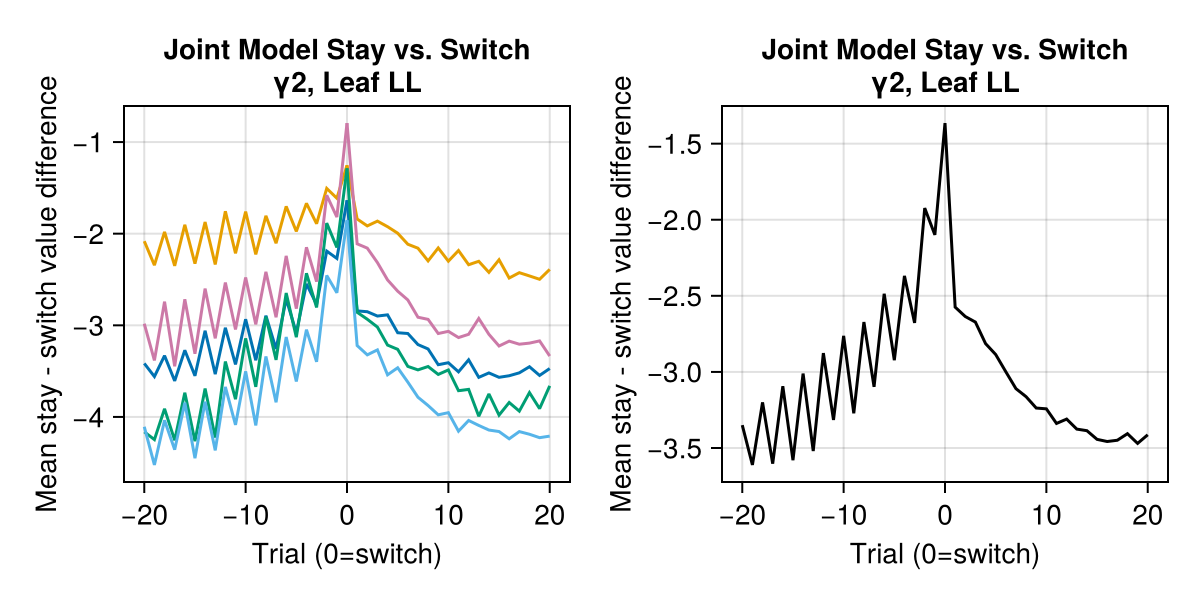

In [ ]:
f = Figure(size=(600,300))
colors = Makie.wong_colors()

nobias_dict = Dict(
    :stay_bias=>0.0,
    :turn_bias=>0.0,
    :spatial_bias=>[0.0, 0.0, 0.0],
)
rewscaled = false
rewscaled_file = rewscaled ? "_rewscaled" : ""
rewscaled_title = rewscaled ? "Rewscaled, " : ""
add_leaf = true
add_leaf_file = add_leaf ? "_leaf" : ""
add_leaf_title = add_leaf ? "" : "No "
add_γ2 = true
add_γ2_file = add_γ2 ? "_γ2" : ""
add_γ2_title = add_γ2 ? "γ2, " : ""

ax1 = Axis(f[1,1], ylabel="Mean stay - switch value difference", xlabel="Trial (0=switch)", title="Joint Model Stay vs. Switch\n$(rewscaled_title)$(add_γ2_title)$(add_leaf_title)Leaf LL")
for (i, animal) in enumerate(animals)
    x1 = load("$(filepath)/results/hmm_biases/hmm$(add_leaf_file)_stay_turn_leafspatial$(add_γ2_file)$(rewscaled_file)_$(animal).jld2", "results")
    q1 = find_Q_vals_hmm(data[animal], x1; add_leaf, rewscaled, delay_turn_bias=false, params=nobias_dict)
    q1[:, :choice_diff] .= log.(1 ./ q1.stem_stay_p .- 1)
    
    choice_diff_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 21) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :choice_diff => mean => :choice_diff)
    choice_diff_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 21) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :choice_diff => mean => :choice_diff)

    lines!(-choice_diff_by_day_q1_pre.n_pre_switch, choice_diff_by_day_q1_pre.choice_diff, color=colors[i], label=animal)
    lines!(choice_diff_by_day_q1_post.n_post_switch, choice_diff_by_day_q1_post.choice_diff, color=colors[i])
end

ax2 = Axis(f[1,2], ylabel="Mean stay - switch value difference", xlabel="Trial (0=switch)", title="Joint Model Stay vs. Switch\n$(rewscaled_title)$(add_γ2_title)$(add_leaf_title)Leaf LL")
choice_diffs = zeros(41)

for (i, animal) in enumerate(animals)
    x1 = load("$(filepath)/results/hmm_biases/hmm$(add_leaf_file)_stay_turn_leafspatial$(add_γ2_file)$(rewscaled_file)_$(animal).jld2", "results")
    q1 = find_Q_vals_hmm(data[animal], x1; add_leaf, rewscaled, delay_turn_bias=false, params=nobias_dict)
    q1[:, :choice_diff] .= log.(1 ./ q1.stem_stay_p .- 1)
    
    choice_diff_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 21) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :choice_diff => mean => :choice_diff)
    choice_diff_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 21) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :choice_diff => mean => :choice_diff)

    choice_diffs[21:-1:1] .+= choice_diff_by_day_q1_pre.choice_diff
    choice_diffs[22:41] .+= choice_diff_by_day_q1_post.choice_diff[2:end]
end
lines!(-20:20, choice_diffs ./ length(animals), color="black")

f

## Without Leaf

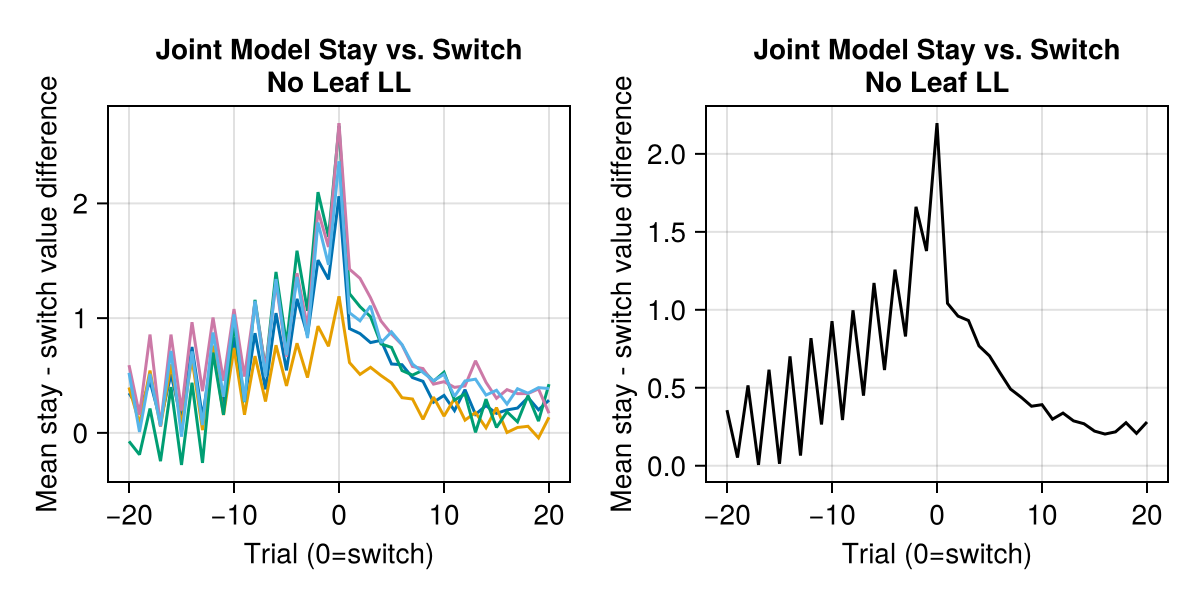

In [ ]:
f = Figure(size=(600,300))
colors = Makie.wong_colors()

nobias_dict = Dict(
    :stay_bias=>0.0,
    :turn_bias=>0.0,
    :spatial_bias=>[0.0, 0.0, 0.0],
)
rewscaled = false
rewscaled_file = rewscaled ? "_rewscaled" : ""
rewscaled_title = rewscaled ? "Rewscaled, " : ""
add_leaf = false
add_leaf_file = add_leaf ? "_leaf" : ""
add_leaf_title = add_leaf ? "" : "No "
add_γ2 = false
add_γ2_file = add_γ2 ? "_γ2" : ""
add_γ2_title = add_γ2 ? "γ2, " : ""

ax1 = Axis(f[1,1], ylabel="Mean stay - switch value difference", xlabel="Trial (0=switch)", title="Joint Model Stay vs. Switch\n$(rewscaled_title)$(add_γ2_title)$(add_leaf_title)Leaf LL")
for (i, animal) in enumerate(animals)
    x1 = load("$(filepath)/results/hmm_biases/hmm$(add_leaf_file)_stay_turn$(add_γ2_file)$(rewscaled_file)_$(animal).jld2", "results")
    q1 = find_Q_vals_hmm(data[animal], x1; add_leaf, rewscaled, delay_turn_bias=false, params=nobias_dict)
    q1[:, :choice_diff] .= log.(1 ./ q1.stem_stay_p .- 1)
    
    choice_diff_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 21) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :choice_diff => mean => :choice_diff)
    choice_diff_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 21) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :choice_diff => mean => :choice_diff)

    lines!(-choice_diff_by_day_q1_pre.n_pre_switch, choice_diff_by_day_q1_pre.choice_diff, color=colors[i], label=animal)
    lines!(choice_diff_by_day_q1_post.n_post_switch, choice_diff_by_day_q1_post.choice_diff, color=colors[i])
end

ax2 = Axis(f[1,2], ylabel="Mean stay - switch value difference", xlabel="Trial (0=switch)", title="Joint Model Stay vs. Switch\n$(rewscaled_title)$(add_γ2_title)$(add_leaf_title)Leaf LL")
choice_diffs = zeros(41)

for (i, animal) in enumerate(animals)
    x1 = load("$(filepath)/results/hmm_biases/hmm$(add_leaf_file)_stay_turn$(add_γ2_file)$(rewscaled_file)_$(animal).jld2", "results")
    q1 = find_Q_vals_hmm(data[animal], x1; add_leaf, rewscaled, delay_turn_bias=false, params=nobias_dict)
    q1[:, :choice_diff] .= log.(1 ./ q1.stem_stay_p .- 1)
    
    choice_diff_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 21) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :choice_diff => mean => :choice_diff)
    choice_diff_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 21) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :choice_diff => mean => :choice_diff)

    choice_diffs[21:-1:1] .+= choice_diff_by_day_q1_pre.choice_diff
    choice_diffs[22:41] .+= choice_diff_by_day_q1_post.choice_diff[2:end]
end
lines!(-20:20, choice_diffs ./ length(animals), color="black")

f

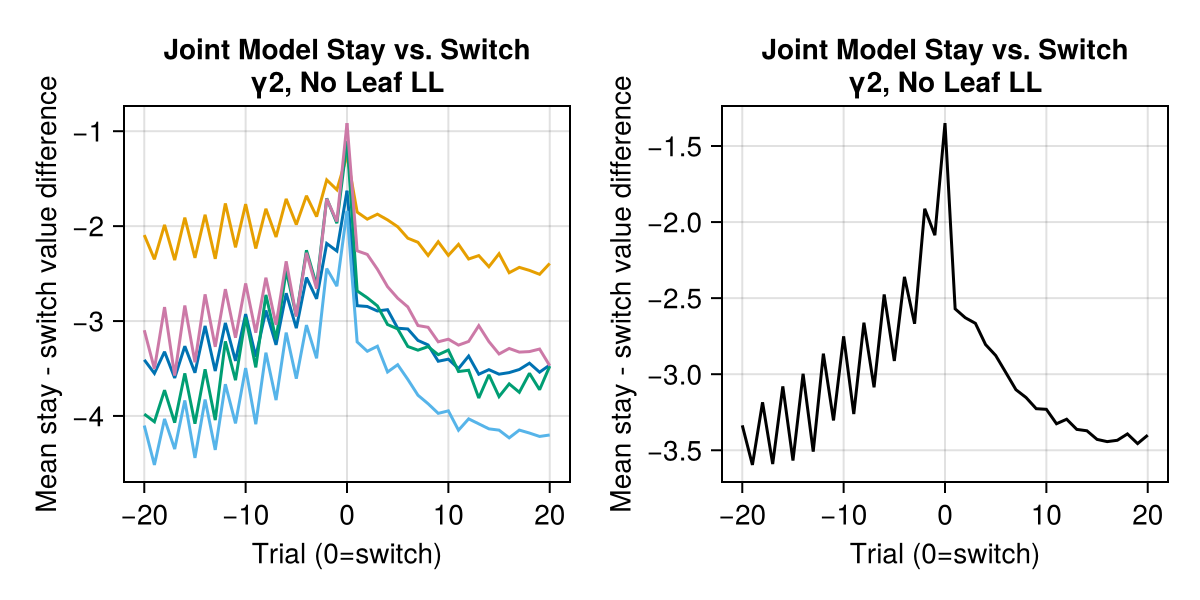

In [ ]:
f = Figure(size=(600,300))
colors = Makie.wong_colors()

nobias_dict = Dict(
    :stay_bias=>0.0,
    :turn_bias=>0.0,
    :spatial_bias=>[0.0, 0.0, 0.0],
)
rewscaled = false
rewscaled_file = rewscaled ? "_rewscaled" : ""
rewscaled_title = rewscaled ? "Rewscaled, " : ""
add_leaf = false
add_leaf_file = add_leaf ? "_leaf" : ""
add_leaf_title = add_leaf ? "" : "No "
add_γ2 = true
add_γ2_file = add_γ2 ? "_γ2" : ""
add_γ2_title = add_γ2 ? "γ2, " : ""

ax1 = Axis(f[1,1], ylabel="Mean stay - switch value difference", xlabel="Trial (0=switch)", title="Joint Model Stay vs. Switch\n$(rewscaled_title)$(add_γ2_title)$(add_leaf_title)Leaf LL")
for (i, animal) in enumerate(animals)
    x1 = load("$(filepath)/results/hmm_biases/hmm$(add_leaf_file)_stay_turn$(add_γ2_file)$(rewscaled_file)_$(animal).jld2", "results")
    q1 = find_Q_vals_hmm(data[animal], x1; add_leaf, rewscaled, delay_turn_bias=false, params=nobias_dict)
    q1[:, :choice_diff] .= log.(1 ./ q1.stem_stay_p .- 1)
    
    choice_diff_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 21) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :choice_diff => mean => :choice_diff)
    choice_diff_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 21) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :choice_diff => mean => :choice_diff)

    lines!(-choice_diff_by_day_q1_pre.n_pre_switch, choice_diff_by_day_q1_pre.choice_diff, color=colors[i], label=animal)
    lines!(choice_diff_by_day_q1_post.n_post_switch, choice_diff_by_day_q1_post.choice_diff, color=colors[i])
end

ax2 = Axis(f[1,2], ylabel="Mean stay - switch value difference", xlabel="Trial (0=switch)", title="Joint Model Stay vs. Switch\n$(rewscaled_title)$(add_γ2_title)$(add_leaf_title)Leaf LL")
choice_diffs = zeros(41)

for (i, animal) in enumerate(animals)
    x1 = load("$(filepath)/results/hmm_biases/hmm$(add_leaf_file)_stay_turn$(add_γ2_file)$(rewscaled_file)_$(animal).jld2", "results")
    q1 = find_Q_vals_hmm(data[animal], x1; add_leaf, rewscaled, delay_turn_bias=false, params=nobias_dict)
    q1[:, :choice_diff] .= log.(1 ./ q1.stem_stay_p .- 1)
    
    choice_diff_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 21) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :choice_diff => mean => :choice_diff)
    choice_diff_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 21) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :choice_diff => mean => :choice_diff)

    choice_diffs[21:-1:1] .+= choice_diff_by_day_q1_pre.choice_diff
    choice_diffs[22:41] .+= choice_diff_by_day_q1_post.choice_diff[2:end]
end
lines!(-20:20, choice_diffs ./ length(animals), color="black")

f

# Independent Models

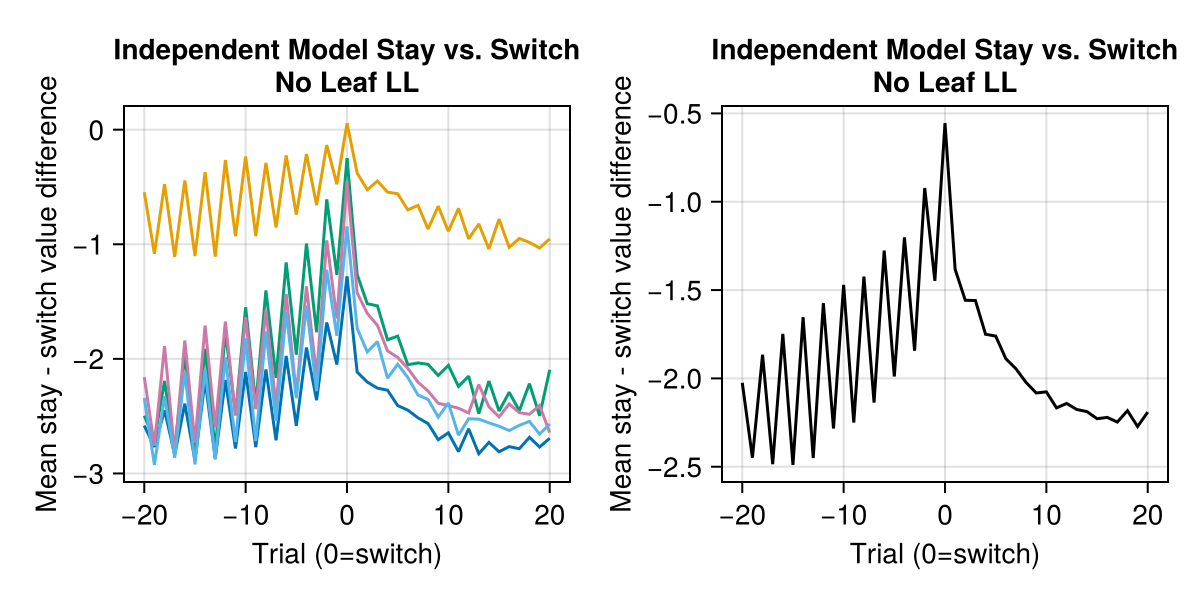

In [ ]:
f = Figure(size=(600,300))
colors = Makie.wong_colors()

nobias_dict = Dict(
    :stay_bias=>0.0,
    :turn_bias=>0.0,
    :spatial_bias=>[0.0, 0.0, 0.0],
)
rewscaled = false
rewscaled_file = rewscaled ? "_rewscaled" : ""
rewscaled_title = rewscaled ? "Rewscaled, " : ""
add_leaf = false
add_leaf_file = add_leaf ? "_leaf" : ""
add_leaf_title = add_leaf ? "" : "No "
add_γ2 = false
add_γ2_file = add_γ2 ? "_γ2" : ""
add_γ2_title = add_γ2 ? "γ2, " : ""

ax1 = Axis(f[1,1], ylabel="Mean stay - switch value difference", xlabel="Trial (0=switch)", title="Independent Model Stay vs. Switch\n$(rewscaled_title)$(add_γ2_title)$(add_leaf_title)Leaf LL")
for (i, animal) in enumerate(animals)
    x1 = load("$(filepath)/results/hmm_independentsamedist_biases/hmm_independentsamedist$(add_leaf_file)_stay_turn$(add_γ2_file)$(rewscaled_file)_$(animal).jld2", "results")
    q1 = find_Q_vals_hmm_independentsamedist(data[animal], x1; add_leaf, rewscaled, delay_turn_bias=false, params=nobias_dict)
    q1[:, :choice_diff] .= log.(1 ./ q1.stem_stay_p .- 1)
    
    choice_diff_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 21) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :choice_diff => mean => :choice_diff)
    choice_diff_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 21) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :choice_diff => mean => :choice_diff)

    lines!(-choice_diff_by_day_q1_pre.n_pre_switch, choice_diff_by_day_q1_pre.choice_diff, color=colors[i], label=animal)
    lines!(choice_diff_by_day_q1_post.n_post_switch, choice_diff_by_day_q1_post.choice_diff, color=colors[i])
end

ax2 = Axis(f[1,2], ylabel="Mean stay - switch value difference", xlabel="Trial (0=switch)", title="Independent Model Stay vs. Switch\n$(rewscaled_title)$(add_γ2_title)$(add_leaf_title)Leaf LL")
choice_diffs = zeros(41)

for (i, animal) in enumerate(animals)
    x1 = load("$(filepath)/results/hmm_independentsamedist_biases/hmm_independentsamedist$(add_leaf_file)_stay_turn$(add_γ2_file)$(rewscaled_file)_$(animal).jld2", "results")
    q1 = find_Q_vals_hmm_independentsamedist(data[animal], x1; add_leaf, rewscaled, delay_turn_bias=false, params=nobias_dict)
    q1[:, :choice_diff] .= log.(1 ./ q1.stem_stay_p .- 1)
    
    choice_diff_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 21) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :choice_diff => mean => :choice_diff)
    choice_diff_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 21) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :choice_diff => mean => :choice_diff)

    choice_diffs[21:-1:1] .+= choice_diff_by_day_q1_pre.choice_diff
    choice_diffs[22:41] .+= choice_diff_by_day_q1_post.choice_diff[2:end]
end
lines!(-20:20, choice_diffs ./ length(animals), color="black")

f

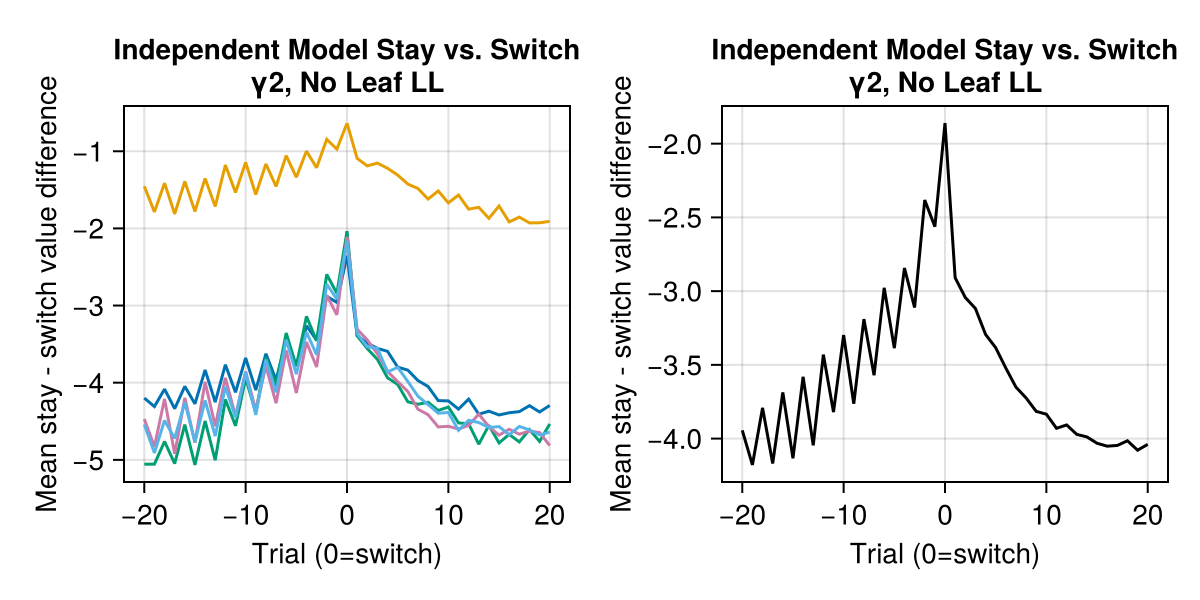

In [ ]:
f = Figure(size=(600,300))
colors = Makie.wong_colors()

nobias_dict = Dict(
    :stay_bias=>0.0,
    :turn_bias=>0.0,
    :spatial_bias=>[0.0, 0.0, 0.0],
)
rewscaled = false
rewscaled_file = rewscaled ? "_rewscaled" : ""
rewscaled_title = rewscaled ? "Rewscaled, " : ""
add_leaf = false
add_leaf_file = add_leaf ? "_leaf" : ""
add_leaf_title = add_leaf ? "" : "No "
add_γ2 = true
add_γ2_file = add_γ2 ? "_γ2" : ""
add_γ2_title = add_γ2 ? "γ2, " : ""

ax1 = Axis(f[1,1], ylabel="Mean stay - switch value difference", xlabel="Trial (0=switch)", title="Independent Model Stay vs. Switch\n$(rewscaled_title)$(add_γ2_title)$(add_leaf_title)Leaf LL")
for (i, animal) in enumerate(animals)
    x1 = load("$(filepath)/results/hmm_independentsamedist_biases/hmm_independentsamedist$(add_leaf_file)_stay_turn$(add_γ2_file)$(rewscaled_file)_$(animal).jld2", "results")
    q1 = find_Q_vals_hmm_independentsamedist(data[animal], x1; add_leaf, rewscaled, delay_turn_bias=false, params=nobias_dict)
    q1[:, :choice_diff] .= log.(1 ./ q1.stem_stay_p .- 1)
    
    choice_diff_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 21) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :choice_diff => mean => :choice_diff)
    choice_diff_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 21) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :choice_diff => mean => :choice_diff)

    lines!(-choice_diff_by_day_q1_pre.n_pre_switch, choice_diff_by_day_q1_pre.choice_diff, color=colors[i], label=animal)
    lines!(choice_diff_by_day_q1_post.n_post_switch, choice_diff_by_day_q1_post.choice_diff, color=colors[i])
end

ax2 = Axis(f[1,2], ylabel="Mean stay - switch value difference", xlabel="Trial (0=switch)", title="Independent Model Stay vs. Switch\n$(rewscaled_title)$(add_γ2_title)$(add_leaf_title)Leaf LL")
choice_diffs = zeros(41)

for (i, animal) in enumerate(animals)
    x1 = load("$(filepath)/results/hmm_independentsamedist_biases/hmm_independentsamedist$(add_leaf_file)_stay_turn$(add_γ2_file)$(rewscaled_file)_$(animal).jld2", "results")
    q1 = find_Q_vals_hmm_independentsamedist(data[animal], x1; add_leaf, rewscaled, delay_turn_bias=false, params=nobias_dict)
    q1[:, :choice_diff] .= log.(1 ./ q1.stem_stay_p .- 1)
    
    choice_diff_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 21) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :choice_diff => mean => :choice_diff)
    choice_diff_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 21) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :choice_diff => mean => :choice_diff)

    choice_diffs[21:-1:1] .+= choice_diff_by_day_q1_pre.choice_diff
    choice_diffs[22:41] .+= choice_diff_by_day_q1_post.choice_diff[2:end]
end
lines!(-20:20, choice_diffs ./ length(animals), color="black")

f

## No Nonlocal

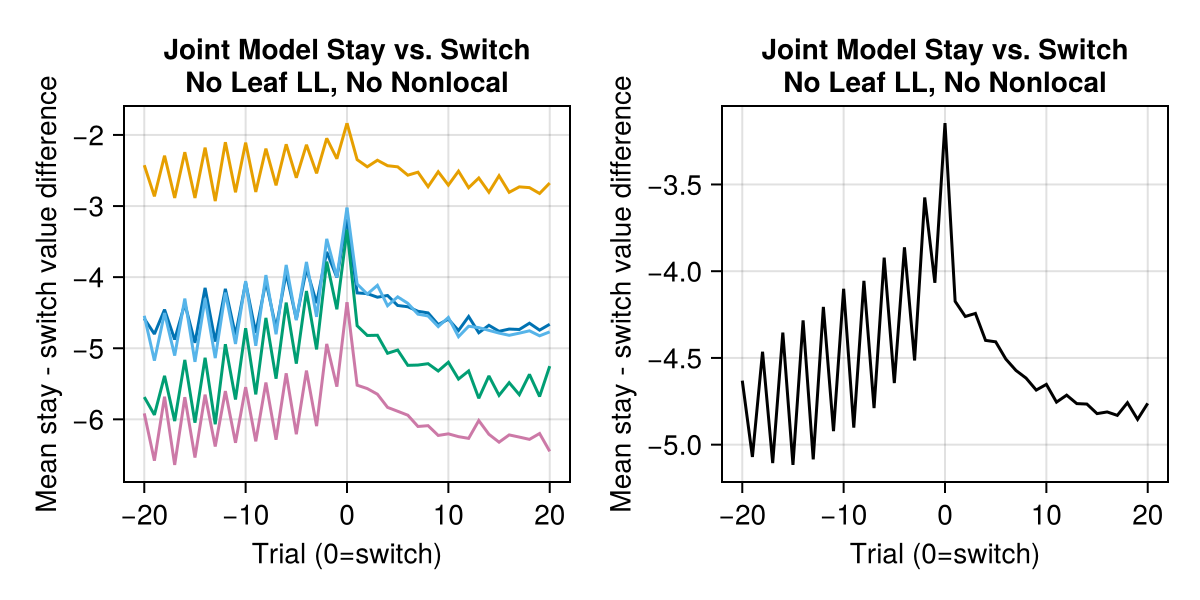

In [ ]:
f = Figure(size=(600,300))
colors = Makie.wong_colors()

nobias_dict = Dict(
    :stay_bias=>0.0,
    :turn_bias=>0.0,
    :spatial_bias=>[0.0, 0.0, 0.0],
)
rewscaled = false
rewscaled_file = rewscaled ? "_rewscaled" : ""
rewscaled_title = rewscaled ? "Rewscaled, " : ""
add_leaf = false
add_leaf_file = add_leaf ? "_leaf" : ""
add_leaf_title = add_leaf ? "" : "No "
add_γ2 = false
add_γ2_file = add_γ2 ? "_γ2" : ""
add_γ2_title = add_γ2 ? "γ2, " : ""

ax1 = Axis(f[1,1], ylabel="Mean stay - switch value difference", xlabel="Trial (0=switch)", title="Joint Model Stay vs. Switch\n$(rewscaled_title)$(add_γ2_title)$(add_leaf_title)Leaf LL, No Nonlocal")
for (i, animal) in enumerate(animals)
    x1 = load("$(filepath)/results/hmm_nononlocal_biases/hmm$(add_leaf_file)_stay_turn$(add_γ2_file)$(rewscaled_file)_$(animal).jld2", "results")
    q1 = find_Q_vals_hmm(data[animal], x1; add_leaf, rewscaled, delay_turn_bias=false, params=nobias_dict)
    q1[:, :choice_diff] .= log.(1 ./ q1.stem_stay_p .- 1)
    
    choice_diff_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 21) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :choice_diff => mean => :choice_diff)
    choice_diff_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 21) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :choice_diff => mean => :choice_diff)

    lines!(-choice_diff_by_day_q1_pre.n_pre_switch, choice_diff_by_day_q1_pre.choice_diff, color=colors[i], label=animal)
    lines!(choice_diff_by_day_q1_post.n_post_switch, choice_diff_by_day_q1_post.choice_diff, color=colors[i])
end

ax2 = Axis(f[1,2], ylabel="Mean stay - switch value difference", xlabel="Trial (0=switch)", title="Joint Model Stay vs. Switch\n$(rewscaled_title)$(add_γ2_title)$(add_leaf_title)Leaf LL, No Nonlocal")
choice_diffs = zeros(41)

for (i, animal) in enumerate(animals)
    x1 = load("$(filepath)/results/hmm_nononlocal_biases/hmm$(add_leaf_file)_stay_turn$(add_γ2_file)$(rewscaled_file)_$(animal).jld2", "results")
    q1 = find_Q_vals_hmm(data[animal], x1; add_leaf, rewscaled, delay_turn_bias=false, params=nobias_dict)
    q1[:, :choice_diff] .= log.(1 ./ q1.stem_stay_p .- 1)
    
    choice_diff_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 21) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :choice_diff => mean => :choice_diff)
    choice_diff_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 21) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :choice_diff => mean => :choice_diff)

    choice_diffs[21:-1:1] .+= choice_diff_by_day_q1_pre.choice_diff
    choice_diffs[22:41] .+= choice_diff_by_day_q1_post.choice_diff[2:end]
end
lines!(-20:20, choice_diffs ./ length(animals), color="black")

f

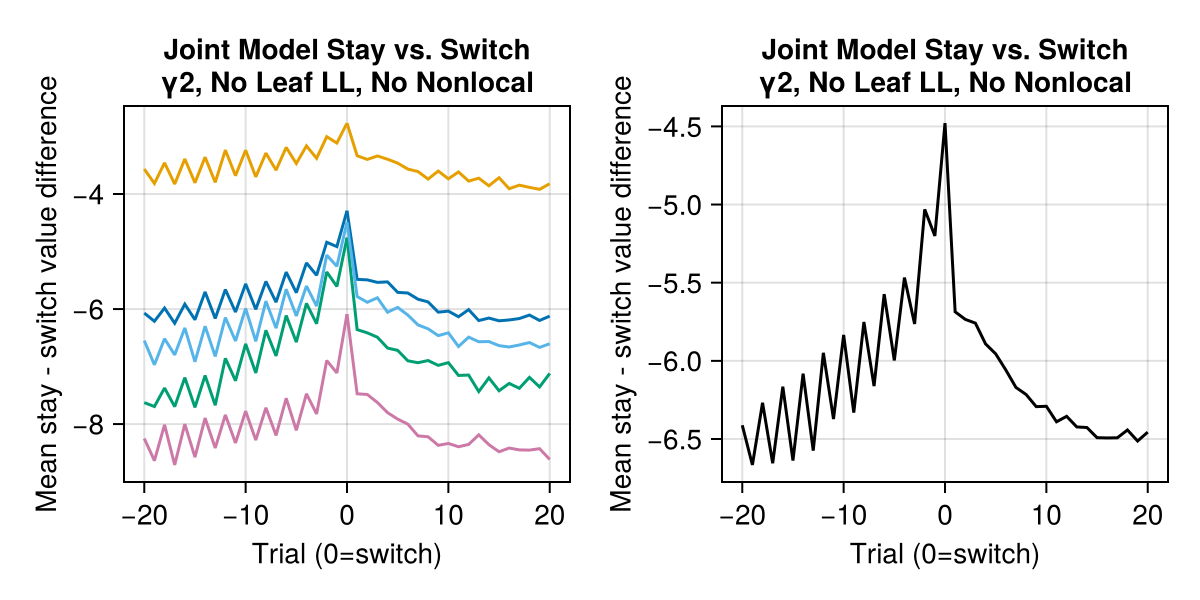

In [ ]:
f = Figure(size=(600,300))
colors = Makie.wong_colors()

nobias_dict = Dict(
    :stay_bias=>0.0,
    :turn_bias=>0.0,
    :spatial_bias=>[0.0, 0.0, 0.0],
)
rewscaled = false
rewscaled_file = rewscaled ? "_rewscaled" : ""
rewscaled_title = rewscaled ? "Rewscaled, " : ""
add_leaf = false
add_leaf_file = add_leaf ? "_leaf" : ""
add_leaf_title = add_leaf ? "" : "No "
add_γ2 = true
add_γ2_file = add_γ2 ? "_γ2" : ""
add_γ2_title = add_γ2 ? "γ2, " : ""

ax1 = Axis(f[1,1], ylabel="Mean stay - switch value difference", xlabel="Trial (0=switch)", title="Joint Model Stay vs. Switch\n$(rewscaled_title)$(add_γ2_title)$(add_leaf_title)Leaf LL, No Nonlocal")
for (i, animal) in enumerate(animals)
    x1 = load("$(filepath)/results/hmm_nononlocal_biases/hmm$(add_leaf_file)_stay_turn$(add_γ2_file)$(rewscaled_file)_$(animal).jld2", "results")
    q1 = find_Q_vals_hmm(data[animal], x1; add_leaf, rewscaled, delay_turn_bias=false, params=nobias_dict)
    q1[:, :choice_diff] .= log.(1 ./ q1.stem_stay_p .- 1)
    
    choice_diff_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 21) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :choice_diff => mean => :choice_diff)
    choice_diff_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 21) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :choice_diff => mean => :choice_diff)

    lines!(-choice_diff_by_day_q1_pre.n_pre_switch, choice_diff_by_day_q1_pre.choice_diff, color=colors[i], label=animal)
    lines!(choice_diff_by_day_q1_post.n_post_switch, choice_diff_by_day_q1_post.choice_diff, color=colors[i])
end

ax2 = Axis(f[1,2], ylabel="Mean stay - switch value difference", xlabel="Trial (0=switch)", title="Joint Model Stay vs. Switch\n$(rewscaled_title)$(add_γ2_title)$(add_leaf_title)Leaf LL, No Nonlocal")
choice_diffs = zeros(41)

for (i, animal) in enumerate(animals)
    x1 = load("$(filepath)/results/hmm_nononlocal_biases/hmm$(add_leaf_file)_stay_turn$(add_γ2_file)$(rewscaled_file)_$(animal).jld2", "results")
    q1 = find_Q_vals_hmm(data[animal], x1; add_leaf, rewscaled, delay_turn_bias=false, params=nobias_dict)
    q1[:, :choice_diff] .= log.(1 ./ q1.stem_stay_p .- 1)
    
    choice_diff_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 21) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :choice_diff => mean => :choice_diff)
    choice_diff_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 21) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :choice_diff => mean => :choice_diff)

    choice_diffs[21:-1:1] .+= choice_diff_by_day_q1_pre.choice_diff
    choice_diffs[22:41] .+= choice_diff_by_day_q1_post.choice_diff[2:end]
end
lines!(-20:20, choice_diffs ./ length(animals), color="black")

f

## Q-Learner

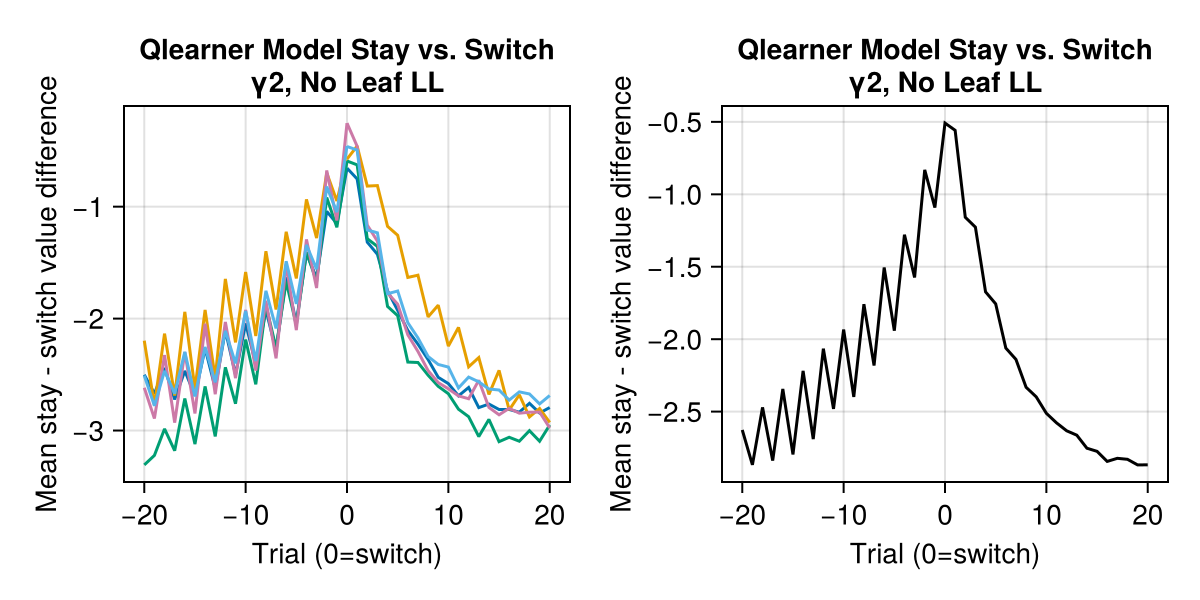

In [ ]:
f = Figure(size=(600,300))
colors = Makie.wong_colors()

nobias_dict = Dict(
    :stay_bias=>0.0,
    :turn_bias=>0.0,
    :spatial_bias=>[0.0, 0.0, 0.0],
)
rewscaled = false
rewscaled_file = rewscaled ? "_rewscaled" : ""
rewscaled_title = rewscaled ? "Rewscaled, " : ""
add_leaf = false
add_leaf_file = add_leaf ? "_leaf" : ""
add_leaf_title = add_leaf ? "" : "No "
add_γ2 = true
add_γ2_file = add_γ2 ? "_γ2" : ""
add_γ2_title = add_γ2 ? "γ2, " : ""

ax1 = Axis(f[1,1], ylabel="Mean stay - switch value difference", xlabel="Trial (0=switch)", title="Qlearner Model Stay vs. Switch\n$(rewscaled_title)$(add_γ2_title)$(add_leaf_title)Leaf LL")
for (i, animal) in enumerate(animals)
    x1 = load("$(filepath)/results/q_biases/q$(add_leaf_file)_initialQ_stay_turn$(add_γ2_file)_decay$(rewscaled_file)_$(animal).jld2", "results")
    q1 = find_Q_vals_qlearner(data[animal], x1; add_leaf, rewscaled, delay_turn_bias=false, params=nobias_dict)
    q1[:, :choice_diff] .= log.(1 ./ q1.stem_stay_p .- 1)
    
    choice_diff_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 21) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :choice_diff => mean => :choice_diff)
    choice_diff_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 21) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :choice_diff => mean => :choice_diff)

    lines!(-choice_diff_by_day_q1_pre.n_pre_switch, choice_diff_by_day_q1_pre.choice_diff, color=colors[i], label=animal)
    lines!(choice_diff_by_day_q1_post.n_post_switch, choice_diff_by_day_q1_post.choice_diff, color=colors[i])
end

ax2 = Axis(f[1,2], ylabel="Mean stay - switch value difference", xlabel="Trial (0=switch)", title="Qlearner Model Stay vs. Switch\n$(rewscaled_title)$(add_γ2_title)$(add_leaf_title)Leaf LL")
choice_diffs = zeros(41)

for (i, animal) in enumerate(animals)
    x1 = load("$(filepath)/results/q_biases/q$(add_leaf_file)_initialQ_stay_turn$(add_γ2_file)_decay$(rewscaled_file)_$(animal).jld2", "results")
    q1 = find_Q_vals_qlearner(data[animal], x1; add_leaf, rewscaled, delay_turn_bias=false, params=nobias_dict)
    q1[:, :choice_diff] .= log.(1 ./ q1.stem_stay_p .- 1)
    
    choice_diff_by_day_q1_pre = combine(groupby(q1[(q1.n_pre_switch .>= 0) .& (q1.n_pre_switch .< 21) .& (q1.stem_stay_p .> 0), :], :n_pre_switch), :choice_diff => mean => :choice_diff)
    choice_diff_by_day_q1_post = combine(groupby(q1[(q1.n_post_switch .>= 0) .& (q1.n_post_switch .< 21) .& (q1.stem_stay_p .> 0), :], :n_post_switch), :choice_diff => mean => :choice_diff)

    choice_diffs[21:-1:1] .+= choice_diff_by_day_q1_pre.choice_diff
    choice_diffs[22:41] .+= choice_diff_by_day_q1_post.choice_diff[2:end]
end
lines!(-20:20, choice_diffs ./ length(animals), color="black")

f